In [1]:
from terratorch import BACKBONE_REGISTRY

import Student
!pip install wilds matplotlib torch torchvision terratorch umap-learn seaborn scikit-learn matplotlib transformers

/home/kevinthomaj/PyCharmMiscProject/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [2]:
import ClusteringPipeline
# ---------------------------------------------------------
#  Simplified DataLoader
# ---------------------------------------------------------
import torch
from pathlib import Path
from PIL import Image
import torchvision.transforms as T
from terratorch.models.backbones.terramind.model.terramind_register import v1_pretraining_mean, v1_pretraining_std

my_root_path = "/mnt/windows/Users/kevin/Downloads/"
def get_input(idx):
        """
        Returns x for a given idx.
        """
        img = Image.open(Path(my_root_path + 'fmow_v1.1') / 'images' / f'rgb_img_{idx}.png').convert('RGB')
        return img

preprocess = T.Compose([
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406],
                         std =[0.229, 0.224, 0.225]),
])



In [ ]:
import FoundationModel

HF_REPO_ID    = "samarkhanna/ExPLoRA"
FILENAME      = "explora_dinov2_fmow_rgb/explora_dinov2_vit_base_fmow_rgb_encoder_only.pth"
ckpt_path = hf_hub_download(repo_id=HF_REPO_ID, filename=FILENAME, local_dir="./checkpoints")
fm_model_base = FoundationModel.FoundationModel(ckpt_path)


2026-04-21 17:14:35,649 - INFO - HTTP Request: HEAD https://huggingface.co/samarkhanna/ExPLoRA/resolve/main/explora_dinov2_fmow_rgb/explora_dinov2_vit_base_fmow_rgb_encoder_only.pth "HTTP/1.1 302 Found"
2026-04-21 17:14:35,650 - WARNING - Warning: You are sending unauthenticated requests to the HF Hub. Please set a HF_TOKEN to enable higher rate limits and faster downloads.
Using cache found in /home/kevinthomaj/.cache/torch/hub/facebookresearch_dinov2_main
/home/kevinthomaj/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
/home/kevinthomaj/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
/home/kevinthomaj/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/block.py:40: UserWarning: xFormers is not available (Block)

In [4]:
import torch.nn as nn
class SimpleMLP(nn.Module):
    def __init__(self, input_dim, hidden_dim=32, num_classes=6):
        super(SimpleMLP, self).__init__()
        self.layer_stack = nn.Sequential(
            # Input to Hidden
            nn.Linear(input_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.GELU(),
            # Optional: Dropout helps significantly with 64 samples/class
            nn.Dropout(0.3),
            # Hidden to Output
            nn.Linear(hidden_dim, num_classes)
        )

    def forward(self, x):
        return self.layer_stack(x)
class LinearProbe(nn.Module):
    def __init__(self, input_dim, num_classes=62):
        super(LinearProbe, self).__init__()
        # Nessun hidden layer, solo una proiezione diretta
        self.classifier = nn.Sequential(
            nn.Linear(input_dim, num_classes),
        )

    def forward(self, x):
        return self.classifier(x)

In [5]:
import FoundationModel
# 1. Setup the pipeline and get full raw metadata
pipeline = ClusteringPipeline.ClusteringPipeline()
df_full = pipeline.get_dataset()
#fm_model_base = FoundationModel.FoundationModel()

df_sample = pipeline.sample_dataset(df_full, samples_per_class=100)

df_train_base = pipeline.get_embeddings(df_sample, fm_model_base, get_input, preprocess,save_path="./dino")


embedding_dim_base = len(df_train_base['embedding'].iloc[0])




--- Sampling 100 images per class ---
Extracting features...


Extracting: 100%|██████████| 49/49 [24:28<00:00, 29.97s/it]


Saving new embeddings dataset to disk...


Clustering embeddings...
Distribution of images across the new macro-classes:
macro_class
2    5200
4     300
5     300
1     200
6     100
3     100
Name: count, dtype: int64


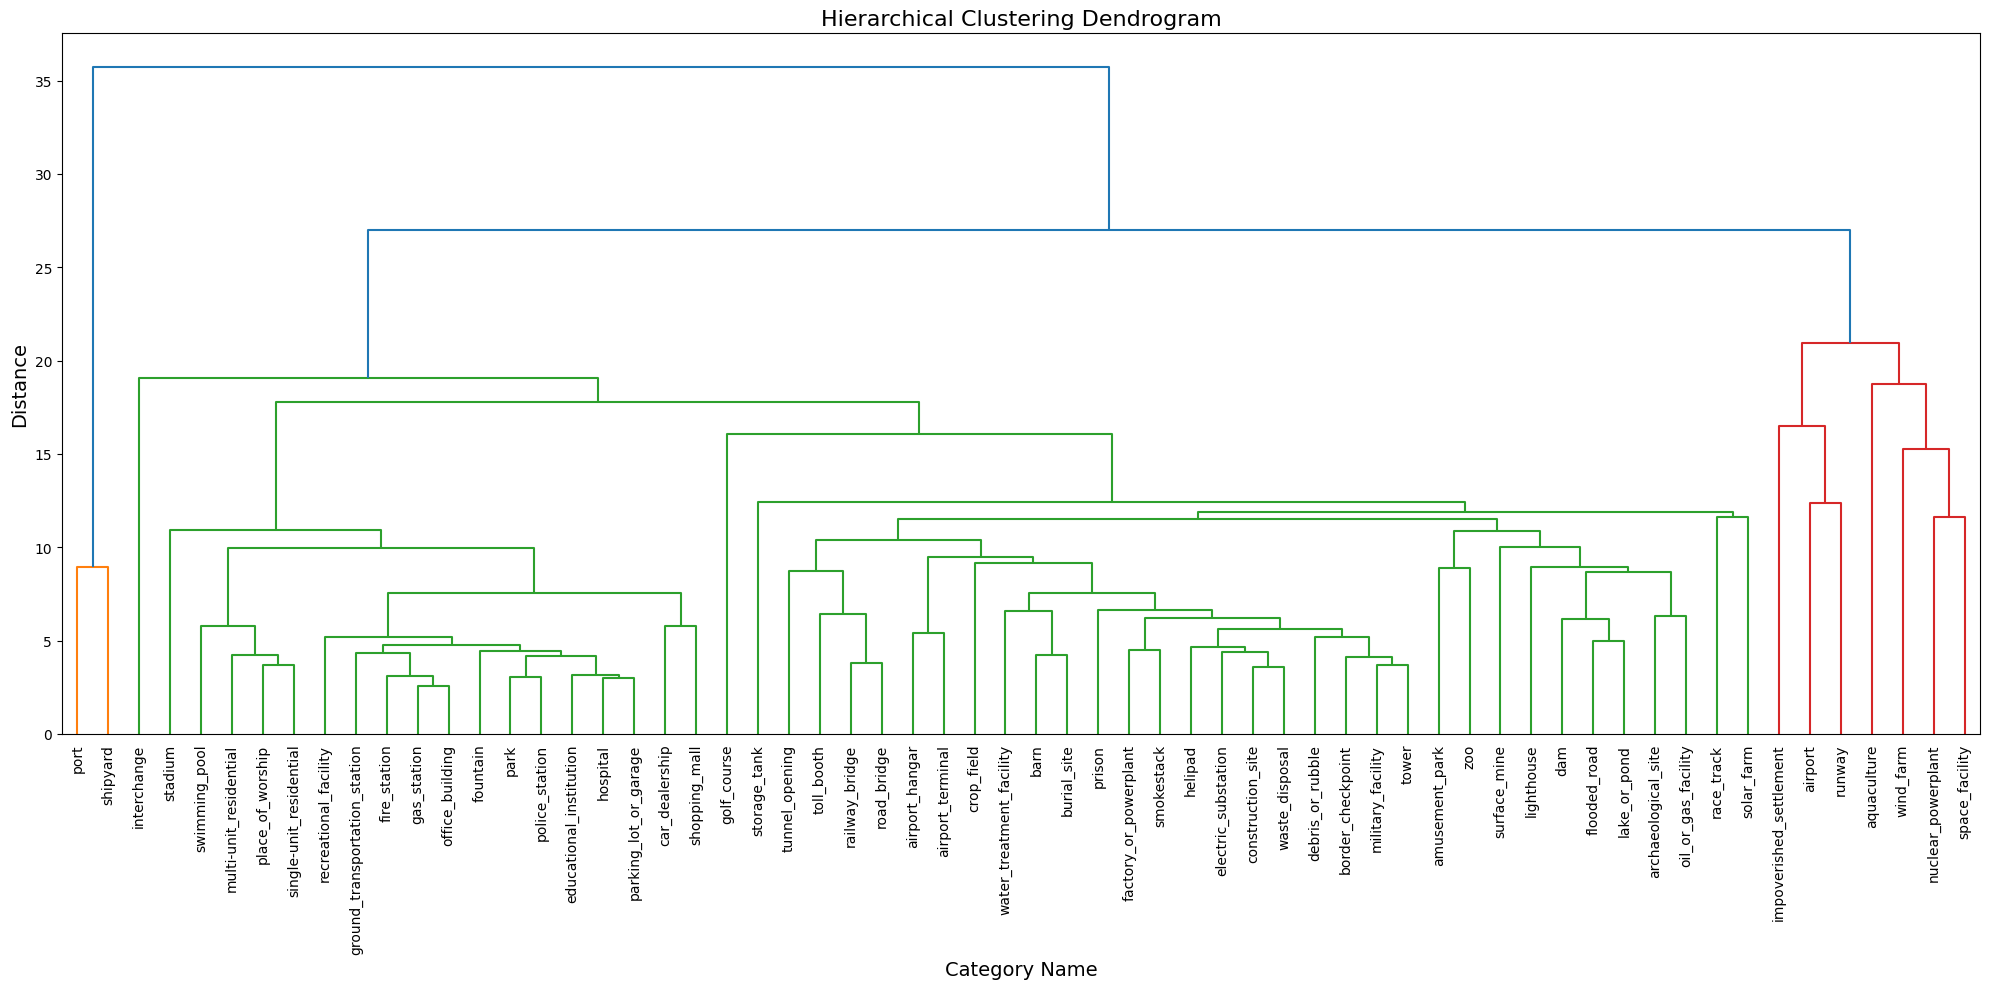

In [6]:
df_train_base = pipeline.cluster_by_class(df_train_base, num_clusters=6)

In [9]:
mlp_model = LinearProbe(input_dim=embedding_dim_base, num_classes=62)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(mlp_model.parameters(), lr=1e-3)

# Train using the newly created macro_class column
history = pipeline.train_offline(
    model=mlp_model,
    df=df_train_base,
    criterion=criterion,
    optimizer=optimizer,
    target_col='category',
    epochs=100
)

Preparing data for training on target: category
Epoch [1/100] | Train Acc: 35.8% | Val Acc: 49.6%
Epoch [5/100] | Train Acc: 75.0% | Val Acc: 54.8%
Epoch [10/100] | Train Acc: 88.0% | Val Acc: 54.8%
Epoch [15/100] | Train Acc: 93.9% | Val Acc: 53.5%
Epoch [20/100] | Train Acc: 97.1% | Val Acc: 52.7%
Epoch [25/100] | Train Acc: 98.7% | Val Acc: 53.0%
Epoch [30/100] | Train Acc: 99.6% | Val Acc: 52.3%
Epoch [35/100] | Train Acc: 99.9% | Val Acc: 52.3%
Epoch [40/100] | Train Acc: 99.9% | Val Acc: 51.6%
Epoch [45/100] | Train Acc: 99.9% | Val Acc: 51.1%


KeyboardInterrupt: 